# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('hotels.csv')

---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [3]:
# Print out summary stats and basic info on the dataset, what trends do you notice?

df.info()

# The data type of reservation status date is a string, but it can be a datetime object. 
# The data type for children is a float when it should be an integer since you can't have a fraction of a child. 
# country has a lot of missing values. 

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
# Calculate prevalence of the target value, how hard of problem is this going to be?
counts = df['is_canceled'].value_counts(normalize = True)
counts

# This problem is going to be moderately difficult since the target variable is somewhat imbalanced. It is not incredibely imbalanced. 

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [5]:
# Check for missing data and drop features with too many missing values, there are some. 

df.isna().sum()
df = df.drop(columns = ['company', 'agent'])

In [6]:
# There are two other features that need to be dropped because they  directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

df = df.drop(columns = ['reservation_status', 'reservation_status_date'])

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [7]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.

# fix the data type for children and fill missing values with 0 since those likely mean there are no children. 
df['children'] = df['children'].fillna(0).astype(int)

# identify categorical and numerical features and the target variable
categorical = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type',
               'assigned_room_type', 'deposit_type', 'customer_type']
numerical = ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights',
             'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
             'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
target = 'is_canceled'

# dataframe for features and target variable, X and y
X = df[categorical + numerical]
y = df[target]

In [8]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42, stratify = y)

---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

In [9]:
# pipeline
preprocessor_m1 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical),
    ('num', MinMaxScaler(), numerical)])

pipeline_m1 = Pipeline(steps = [
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(max_iter = 5000, random_state = 42, n_jobs = -1))])

pipeline_m1.fit(X_train, y_train)

/workspaces/Logistic-Regression-Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

---
 Model 1 Evaluation: Now that the model is built, lets evaluate the model using confusion matrix and ROC/AUC. Given the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

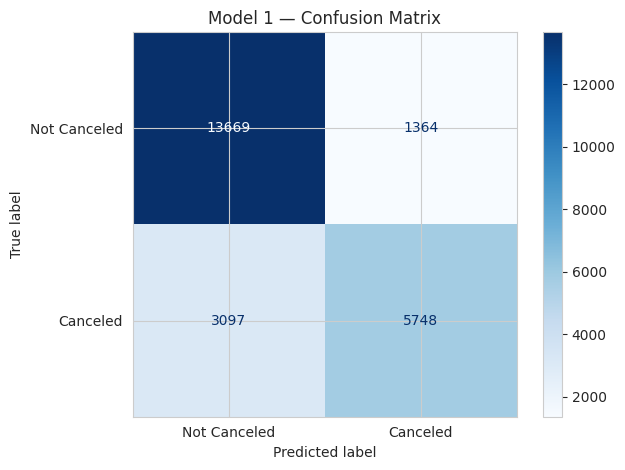

              precision    recall  f1-score   support

Not Canceled       0.82      0.91      0.86     15033
    Canceled       0.81      0.65      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.78      0.79     23878
weighted avg       0.81      0.81      0.81     23878



In [10]:
# confusion matrix
y_pred_m1 = pipeline_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Not Canceled', 'Canceled'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Not Canceled', 'Canceled']))

# The model has high precision in predicting, however, it has a low recall meaning that the model is missing 35% of canceled bookings. 

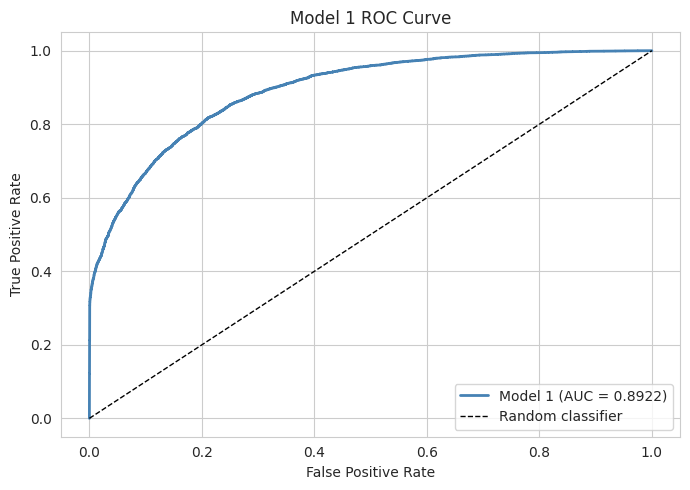

Model 1 ROC-AUC: 0.8922


In [11]:
# ROC-AUC curve
y_proba_m1 = pipeline_m1.predict_proba(X_test)[:, 1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

# The model has an AUC of 0.85 which is pretty good. It means that the model is able to distinguish between canceled 
# and not canceled bookings 85% of the time.

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?


In [12]:
# pipeline 2
preprocessor_m2 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical),
    ('num', MinMaxScaler(), numerical)])

pipeline_m2 = Pipeline(steps = [
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(
        max_iter = 5000, 
        solver = 'saga', 
        penalty = 'elasticnet', 
        l1_ratio = 0.5,
        random_state = 42, 
        n_jobs = -1))])

pipeline_m2.fit(X_train, y_train)

/workspaces/Logistic-Regression-Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/Logistic-Regression-Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

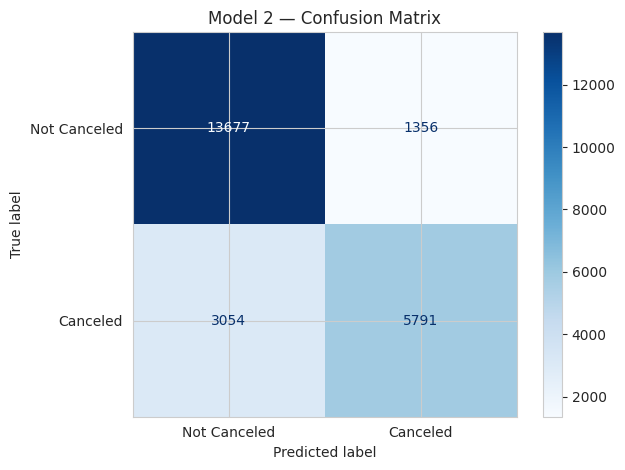

              precision    recall  f1-score   support

Not Canceled       0.82      0.91      0.86     15033
    Canceled       0.81      0.65      0.72      8845

    accuracy                           0.82     23878
   macro avg       0.81      0.78      0.79     23878
weighted avg       0.81      0.82      0.81     23878



In [13]:
# confusion matrix
y_pred_m2 = pipeline_m2.predict(X_test)
cm_m2 = confusion_matrix(y_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Not Canceled', 'Canceled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m2, target_names=['Not Canceled', 'Canceled']))

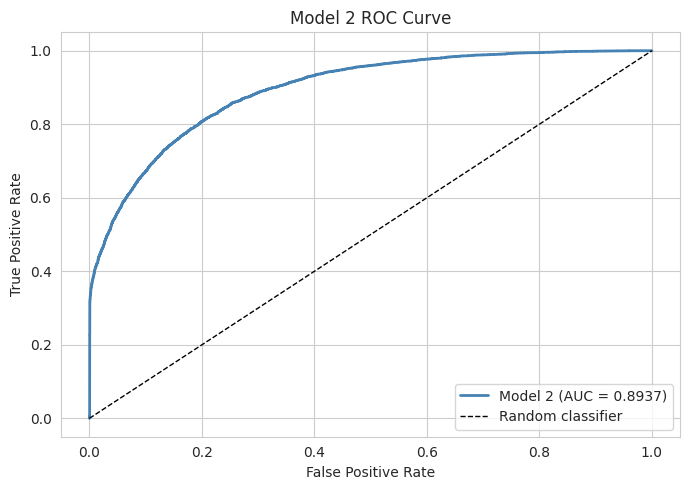

Model 2 ROC-AUC: 0.8937


In [14]:
# # ROC-AUC curve
y_proba_m2 = pipeline_m2.predict_proba(X_test)[:, 1]
fpr_m2, tpr_m2, thresholds = roc_curve(y_test, y_proba_m2)
auc_m2 = roc_auc_score(y_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 ROC-AUC: {auc_m2:.4f}")

# Model 2 has a slightly higher AUC than Model 1. 

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [15]:
# pipeline 3
preprocessor_m3 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical),
    ('num', MinMaxScaler(), numerical)])

pipeline_m3 = Pipeline(steps = [
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(class_weight = 'balanced', max_iter = 5000, random_state = 42))])

pipeline_m3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [16]:
# experiment: change number of folds

# 5 folds
cv_5 = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
scores_5 = cross_val_score(pipeline_m3, X_train, y_train, cv = cv_5, scoring = 'roc_auc')
# 10 folds
cv_10 = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
scores_10 = cross_val_score(pipeline_m3, X_train, y_train, cv = cv_10, scoring = 'roc_auc')

print(f"Mean AUC (5-fold): {scores_5.mean():.4f}")
print(f"Mean AUC (10-fold): {scores_10.mean():.4f}")

# The AUC is very slightly higher in 10 folds than in 5 folds. The difference is not significant.

Mean AUC (5-fold): 0.8929
Mean AUC (10-fold): 0.8935


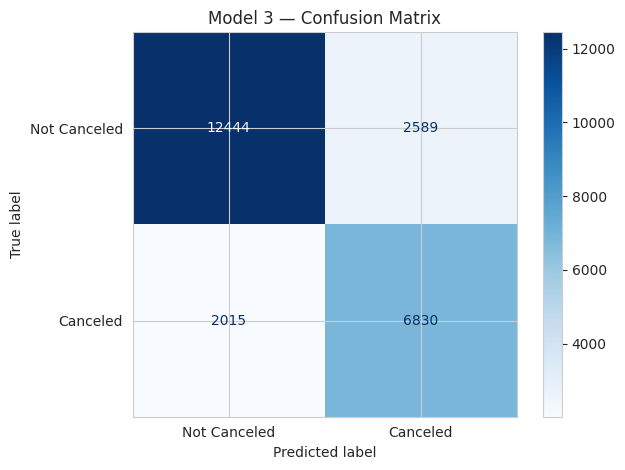

              precision    recall  f1-score   support

Not Canceled       0.86      0.83      0.84     15033
    Canceled       0.73      0.77      0.75      8845

    accuracy                           0.81     23878
   macro avg       0.79      0.80      0.80     23878
weighted avg       0.81      0.81      0.81     23878



In [17]:
# experiment: removing `class_weight = 'balanced'`

# confusion matrix with balanced class weights
y_pred_m3 = pipeline_m3.predict(X_test)
cm_m3 = confusion_matrix(y_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Not Canceled', 'Canceled'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m3, target_names=['Not Canceled', 'Canceled']))

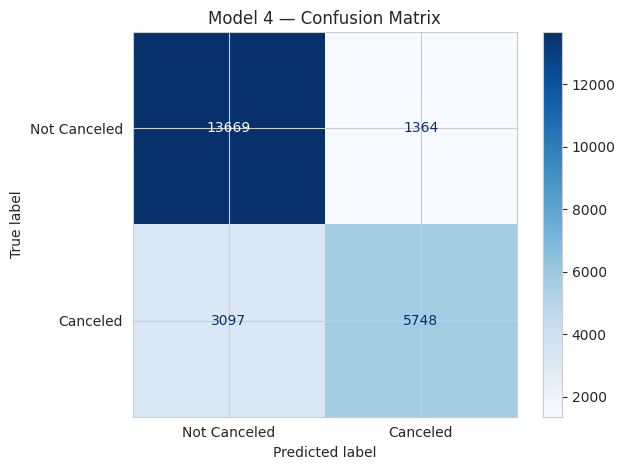

              precision    recall  f1-score   support

Not Canceled       0.82      0.91      0.86     15033
    Canceled       0.81      0.65      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.78      0.79     23878
weighted avg       0.81      0.81      0.81     23878



In [18]:
# confusion matrix without balanced class weights
pipeline_m4 = Pipeline(steps = [
    ('prep',  preprocessor_m3),
    ('model', LogisticRegression(max_iter = 5000, random_state = 42))])
pipeline_m4.fit(X_train, y_train)

y_pred_m4 = pipeline_m4.predict(X_test)
cm_m4 = confusion_matrix(y_test, y_pred_m4)
disp_m4 = ConfusionMatrixDisplay(confusion_matrix=cm_m4, display_labels=['Not Canceled', 'Canceled'])
disp_m4.plot(cmap='Blues')
plt.title('Model 4 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m4, target_names=['Not Canceled', 'Canceled']))

# The model with balanced class weights has a higher recall for the canceled class than the model without balanced class weights. 

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

Based on the analysis, I recommend moving forward with model 3 (logisitic regression with balanced class weights). While the baseline models achieved high accuracy, they frequently failed to identify 35% of actual cancellations, leaving significant revenue at risk. By implementing balanced class weights and validating the results across multiple data folds, Model 3 provides a more robust system that prioritizes catching potential cancellations before they occur. 

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

In [19]:
# 1. 
param_grid = {'model__C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(pipeline_m3, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# 2. 
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
numerical2 = numerical + ['total_nights']

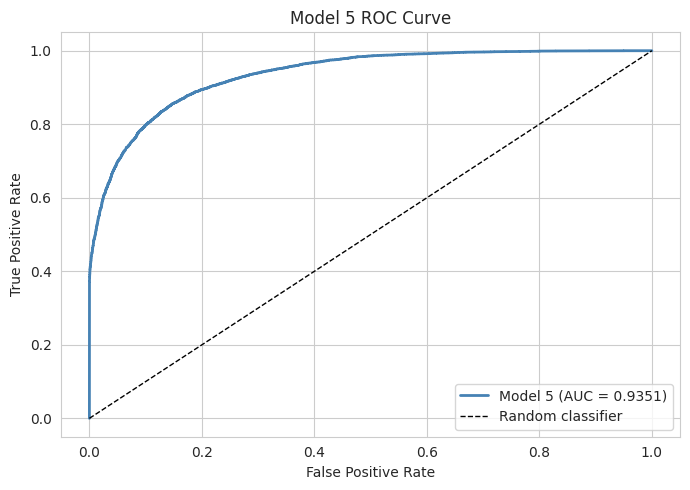

Model 5 ROC-AUC: 0.9351


In [20]:
# 3. 
# pipeline 5
X2 = df[categorical + numerical2]

X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size = 0.20, random_state = 42, stratify = y)

preprocessor_m5 = ColumnTransformer(transformers = [
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical),
    ('num', MinMaxScaler(), numerical2)])

pipeline_m5 = Pipeline(steps = [
    ('prep',  preprocessor_m5),
    ('model', RandomForestClassifier(n_estimators=100,
    max_depth=15, 
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
))])
pipeline_m5.fit(X2_train, y_train)

# AUC
y_proba_m5 = pipeline_m5.predict_proba(X2_test)[:, 1]
fpr_m5, tpr_m5, thresholds = roc_curve(y_test, y_proba_m5)
auc_m5 = roc_auc_score(y_test, y_proba_m5)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m5, tpr_m5, lw=2, color='steelblue', label=f'Model 5 (AUC = {auc_m5:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 5 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 5 ROC-AUC: {auc_m5:.4f}")

# The AUC increases

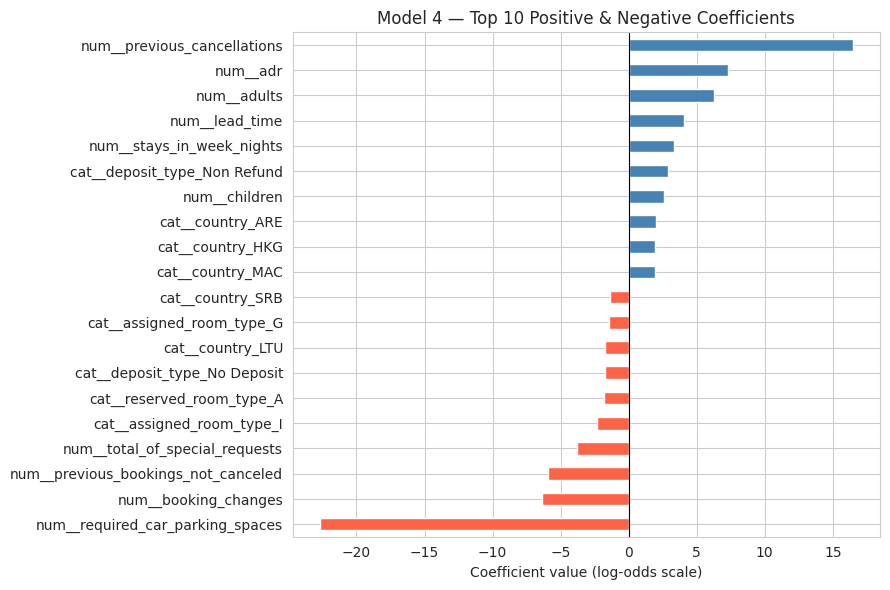

In [21]:
# 4. 
ohe_features = pipeline_m4.named_steps['prep'].transformers_[0][1].get_feature_names_out(categorical)
feature_names_m4 = pipeline_m4.named_steps['prep'].get_feature_names_out()
coefs_m4 = pd.Series(
    pipeline_m4.named_steps['model'].coef_[0],
    index=feature_names_m4
).sort_values()

top_coefs = pd.concat([coefs_m4.head(10), coefs_m4.tail(10)])
top_coefs.plot(kind='barh', figsize=(9, 6), color=top_coefs.map(lambda v: 'steelblue' if v >= 0 else 'tomato'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Model 4 — Top 10 Positive & Negative Coefficients')
plt.xlabel('Coefficient value (log-odds scale)')
plt.tight_layout()
plt.show()